## Heart Disease Prediction

**Goal:** Predict whether a patient has heart disease based on clinical features.
**Dataset:** UCI Heart Disease — 920 patients, 16 features, numerical target (We will chabge it to binary).
**Approach:** EDA → Preprocessing Pipeline → 3 Models → Cross-validation → GridSearchCV tuning

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier

In [ ]:
df = pd.read_csv('heart_disease_uci.csv')
print(df.shape)
print(df.head())
print(df.isnull().sum())
print(df.dtypes)
categorical_features = ['sex', 'cp', 'restecg', 'fbs', 'exang', 'slope', 'thal']

(920, 16)
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0 

In [30]:
# Target 'num': 0 = no disease, 1/2/3/4 = disease present
# Binarize to 0 vs 1 for clean binary classification
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['id', 'dataset', 'num'], errors='ignore')

print('Target distribution:')
print(df['target'].value_counts())
print(f'\nClass balance: {df["target"].mean():.2%} positive (heart disease)')

print('\nNull counts:')
print(df.isnull().sum().sort_values(ascending=False))

Target distribution:
target
1    509
0    411
Name: count, dtype: int64

Class balance: 55.33% positive (heart disease)

Null counts:
ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
thalch       55
exang        55
chol         30
restecg       2
cp            0
sex           0
age           0
target        0
dtype: int64


### Observations
- Target is reasonably balanced (~55% positive) — accuracy is a valid metric here
- Several columns have missing values: `thal`, `ca`, `slope`, `thalch`, `oldpeak`, `chol`, `trestbps`, `fbs`, `restecg`, `exang`
- Mixed types: numeric (`age`, `trestbps`, `chol`) and categorical (`cp`, `restecg`, `thal`)
- Pipeline will handle all nulls — no manual filling needed

## First Step
EDA

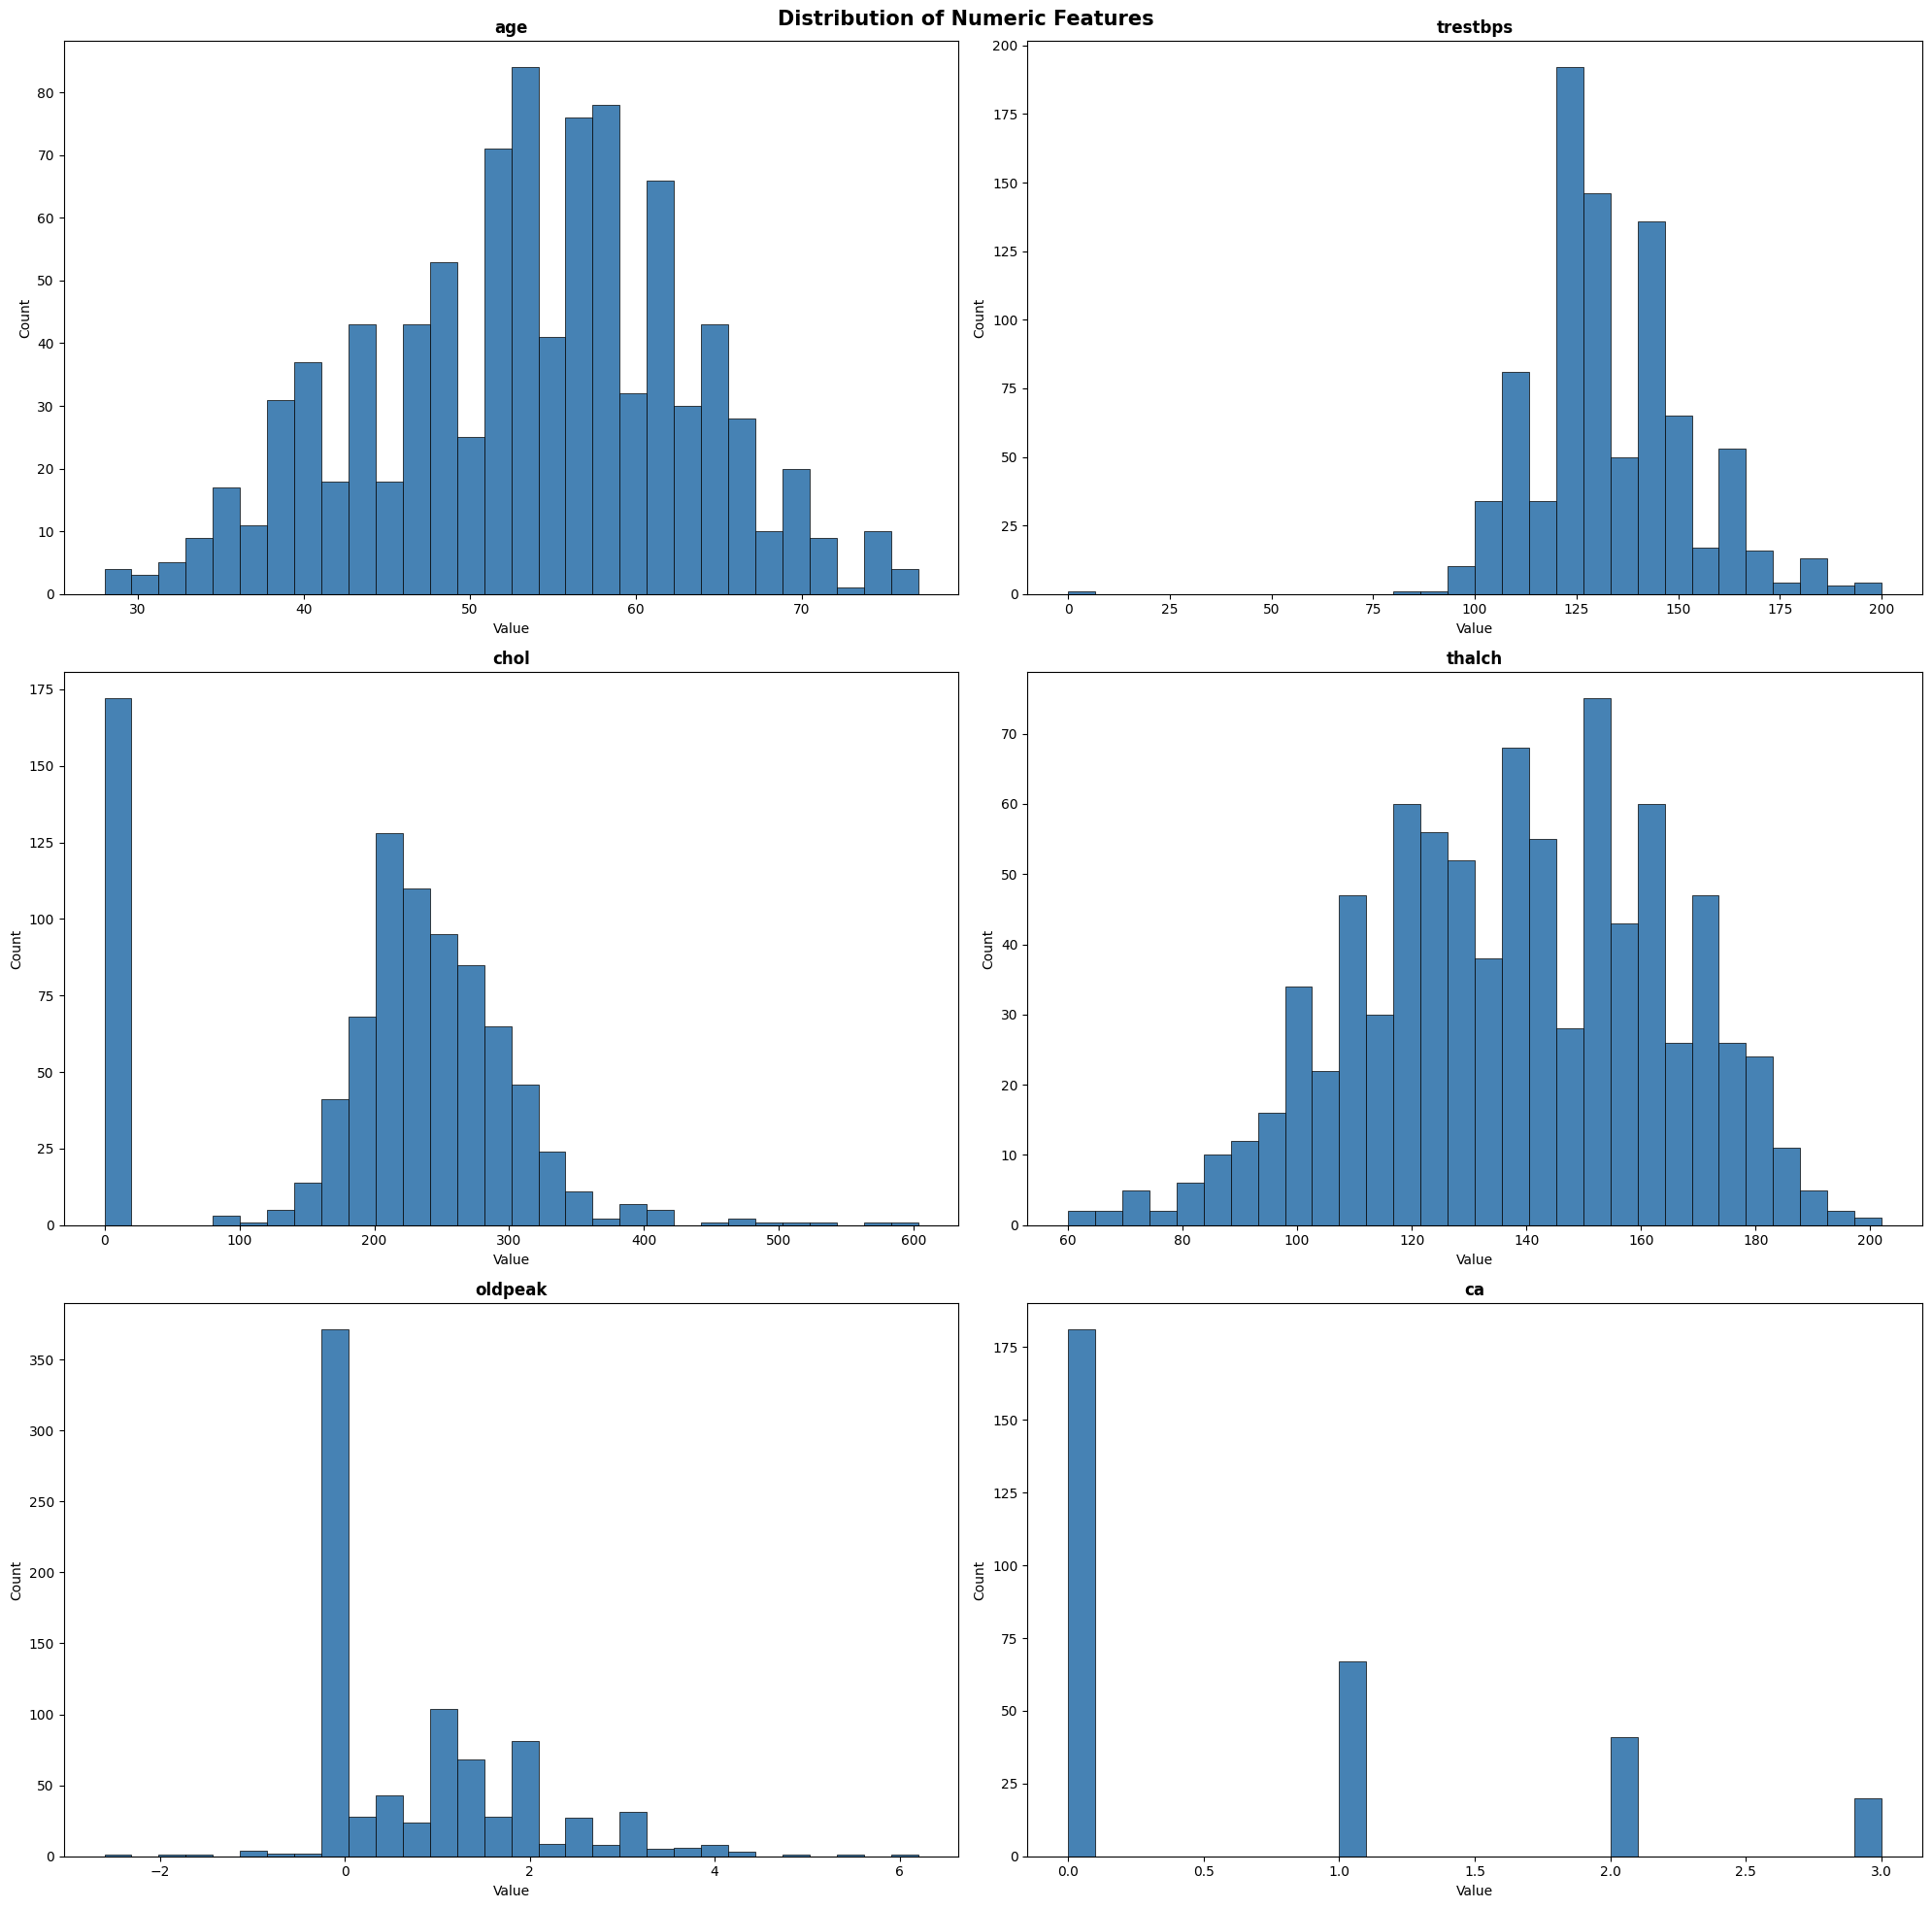

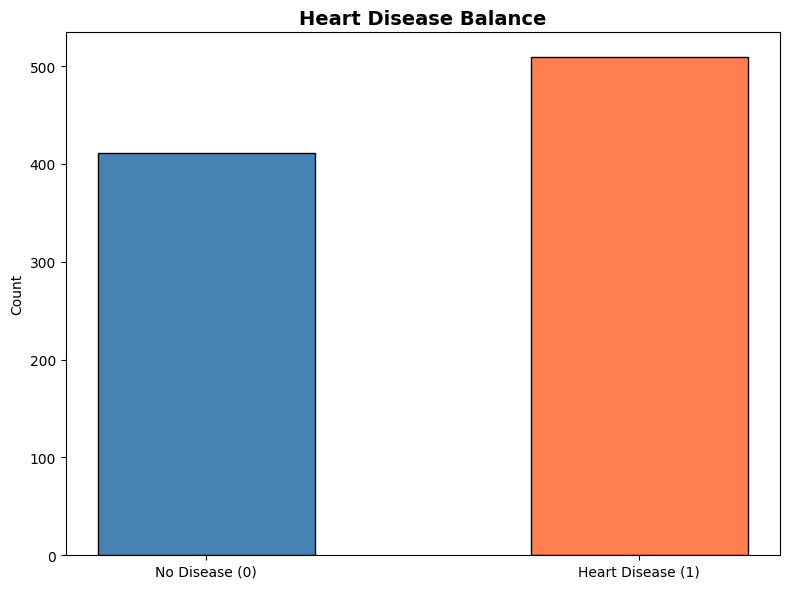

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (2,) and arg 1 with shape (2, 13).

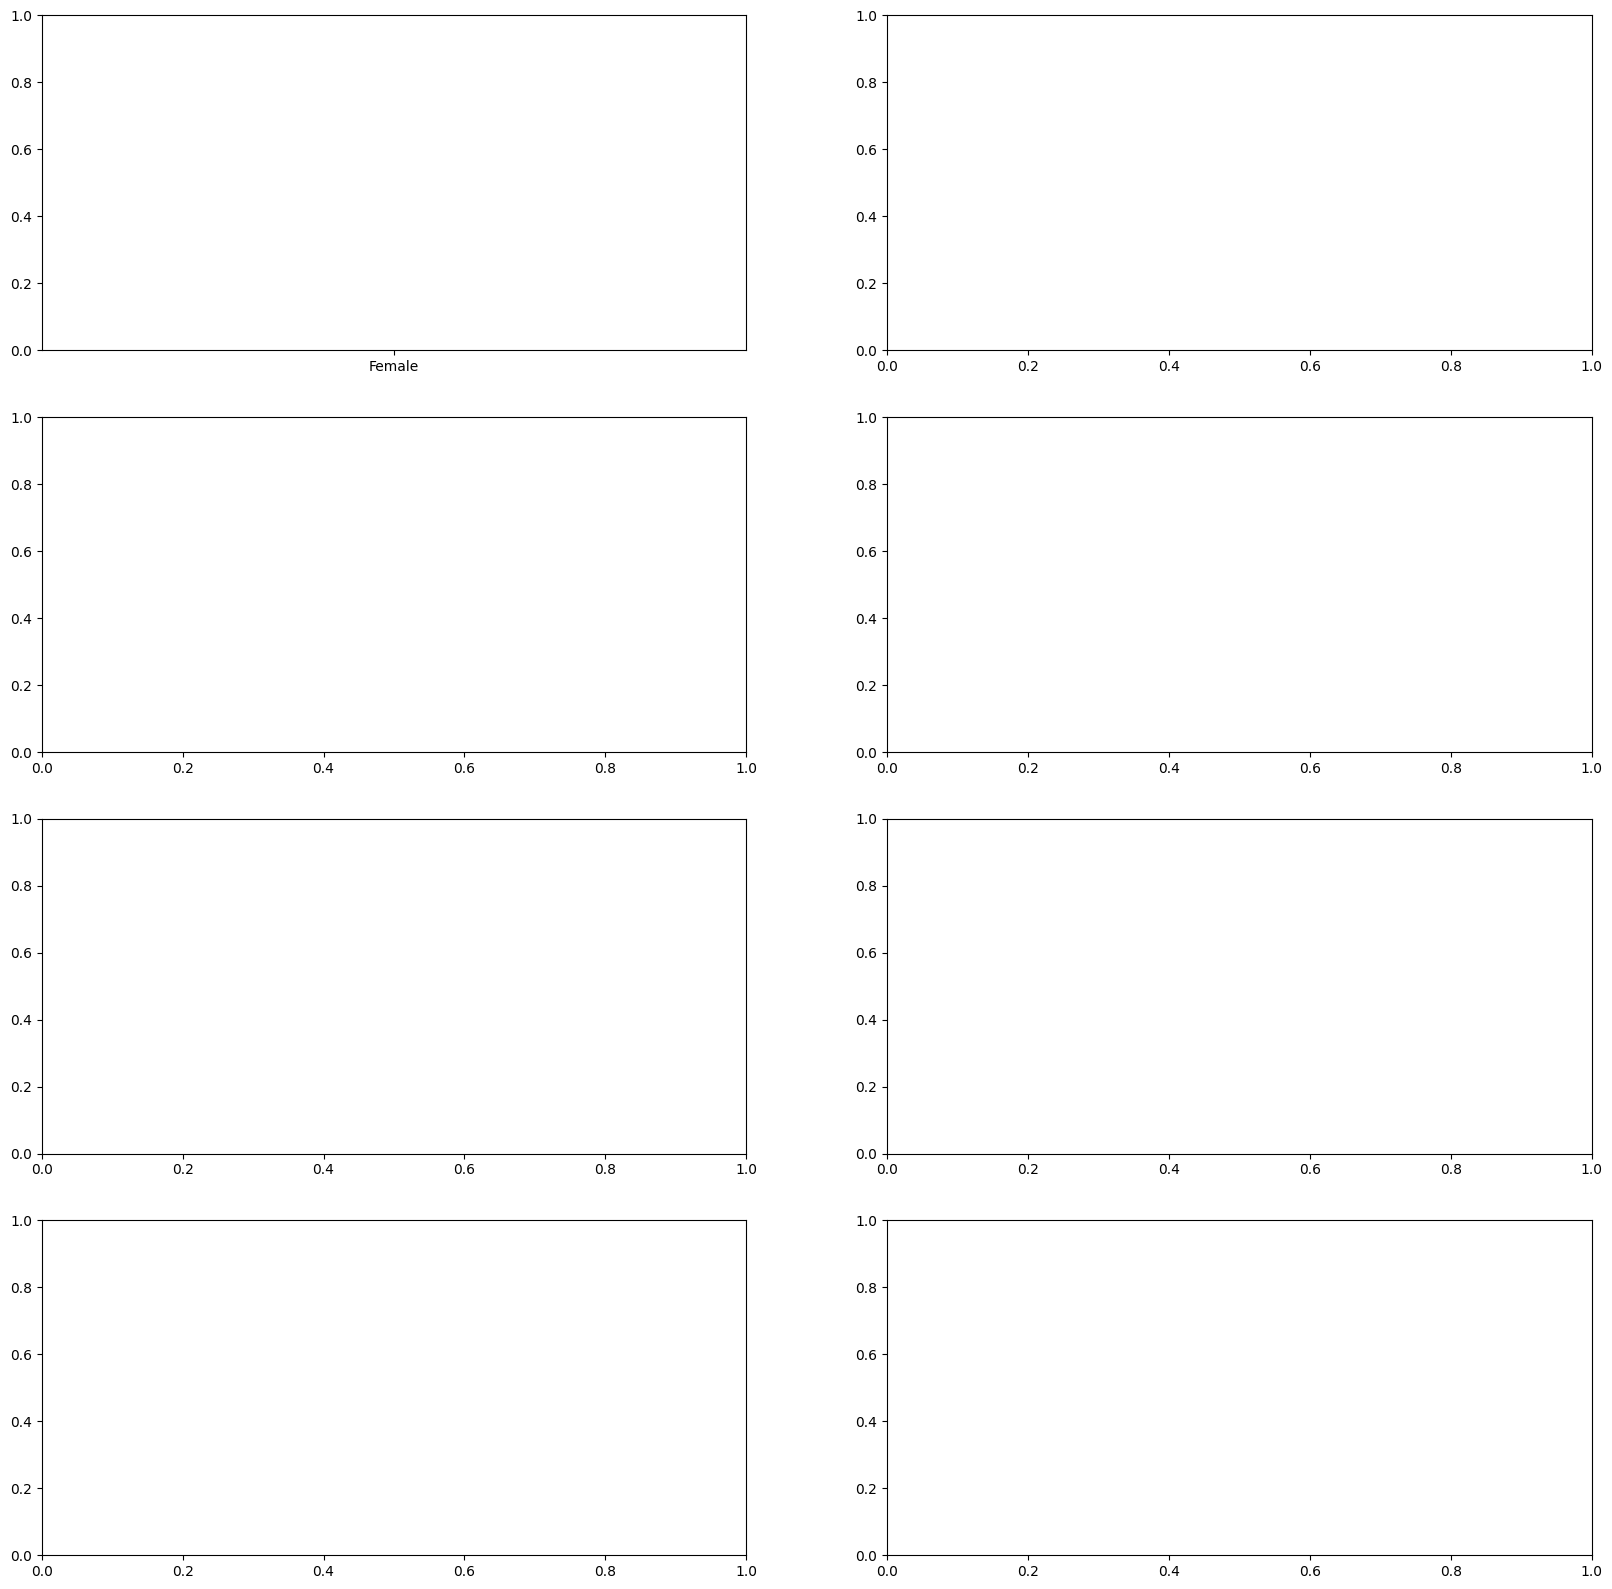

In [ ]:
numeric_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

fig, axes = plt.subplots(3, 2, figsize = (20, 20))
axes = axes.flatten()
for i, feature in enumerate(numeric_features):
    axes[i].hist(df[feature], bins = 30, color = 'Steelblue', edgecolor = 'black', linewidth = 0.5)
    axes[i].set_title(feature, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
plt.suptitle('Distribution of Numeric Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

#### Display Target Values
fig, ax = plt.subplots(figsize = (8 , 6))
counts = df.groupby('target').target.count()
ax.bar(['No Disease (0)', 'Heart Disease (1)'], counts.values, color=['steelblue', 'coral'], edgecolor='black', width=0.5)
ax.set_title('Heart Disease Balance', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

categorical_features = ['sex', 'cp', 'restecg', 'fbs', 'exang', 'slope', 'thal']

fig, axes = plt.subplots(4, 2, figsize = (20, 20))
axes = axes.flatten()
for i, feature in enumerate(categorical_features):
    counts = df.groupby(feature).feature.count()
    axes[i].bar(counts.index, counts.values, color = 'Steelblue', edgecolor = 'balck')
    axes[i].set_title(feature, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Category')
    axes[i].set_ylabel('Value')
plt.suptitle('Distribution of Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 2: Preprocessing Pipeline

**Decisions made:**
- **Numeric features:** impute with median (robust to outliers), then StandardScaler
- **Categorical features:** impute with most_frequent, then OneHotEncoder